Training with FractionalSGD...
Epoch 200/10000, Loss: 0.315453
Epoch 400/10000, Loss: 0.157985
Epoch 600/10000, Loss: 0.135066
Epoch 800/10000, Loss: 0.152763
Epoch 1000/10000, Loss: 0.285840
Epoch 1200/10000, Loss: 1.015280
Epoch 1400/10000, Loss: 0.993528
Epoch 1600/10000, Loss: 2.048645
Epoch 1800/10000, Loss: 3.521520
Epoch 2000/10000, Loss: 2.438607
Epoch 2200/10000, Loss: 1.393835
Epoch 2400/10000, Loss: 0.987589
Epoch 2600/10000, Loss: 1.765273
Epoch 2800/10000, Loss: 1.249398
Epoch 3000/10000, Loss: 2.968960
Epoch 3200/10000, Loss: 2.243625
Epoch 3400/10000, Loss: 1.238005
Epoch 3600/10000, Loss: 0.858326
Epoch 3800/10000, Loss: 0.256675
Epoch 4000/10000, Loss: 0.183138
Epoch 4200/10000, Loss: 0.243262
Epoch 4400/10000, Loss: 0.191141
Epoch 4600/10000, Loss: 0.065127
Epoch 4800/10000, Loss: 0.083663
Epoch 5000/10000, Loss: 0.087454
Epoch 5200/10000, Loss: 0.112718
Epoch 5400/10000, Loss: 0.085371
Epoch 5600/10000, Loss: 0.045424
Epoch 5800/10000, Loss: 0.055709
Epoch 6000/10000

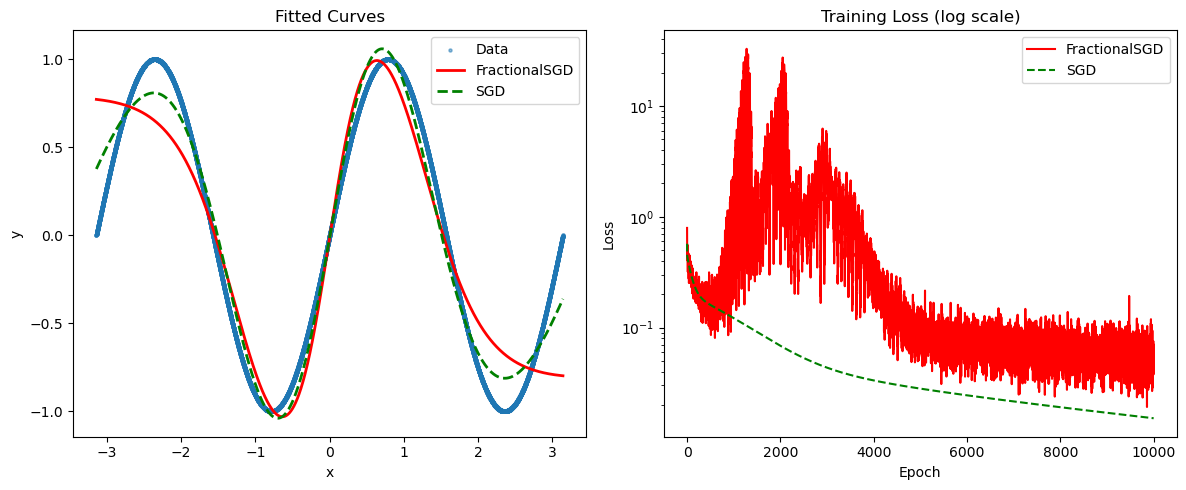

In [31]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from collections import deque
import math

# ====================== FractionalSGD 定义 ======================
class FractionalSGD(optim.Optimizer):
    def __init__(self, params, lr=1e-3, alpha=0.5, memory=10, weight_decay=0):
        if not 0.0 < alpha < 1.0:
            raise ValueError(f"alpha must be in (0,1), got {alpha}")
        if memory <= 0:
            raise ValueError(f"memory must be positive, got {memory}")

        defaults = dict(lr=lr, alpha=alpha, memory=memory, weight_decay=weight_decay)
        super(FractionalSGD, self).__init__(params, defaults)

    def _compute_weights(self, alpha, length):
        """计算长度为 length 的幂律权重 (归一化)"""
        k = torch.arange(length, dtype=torch.float)
        weights = (k + 1) ** (alpha - 1)
        return weights / weights.sum()

    @torch.no_grad()
    def step(self, closure=None):
        loss = None
        if closure is not None:
            with torch.enable_grad():
                loss = closure()

        for group in self.param_groups:
            lr = group['lr']
            alpha = group['alpha']
            memory = group['memory']
            weight_decay = group['weight_decay']

            for p in group['params']:
                if p.grad is None:
                    continue
                grad = p.grad
                if weight_decay != 0:
                    grad = grad.add(p, alpha=weight_decay)

                state = self.state[p]

                # 初始化历史梯度队列
                if 'grad_history' not in state:
                    state['grad_history'] = deque(maxlen=memory)
                    state['weights'] = self._compute_weights(alpha, memory).to(grad.device)

                # 保存当前梯度
                hist = state['grad_history']
                hist.append(grad.clone())  # 克隆以避免后续被修改

                cur_len = len(hist)
                if cur_len < memory:
                    weights = self._compute_weights(alpha, cur_len).to(grad.device)
                else:
                    weights = state['weights']

                # 计算加权梯度
                weighted_grad = torch.zeros_like(grad)
                for i, g in enumerate(hist):
                    w_idx = cur_len - 1 - i
                    weighted_grad.add_(g, alpha=weights[w_idx])

                # 更新参数
                p.add_(weighted_grad, alpha=-lr)

        return loss


# ====================== 验证实验 ======================
def generate_data(n_samples=500):
    """生成正弦函数数据，加噪声"""
    x = np.linspace(-np.pi, np.pi, n_samples)
    y = np.sin(2*x)
    return torch.tensor(x, dtype=torch.float32).view(-1, 1), torch.tensor(y, dtype=torch.float32).view(-1, 1)

def train_model(model, optimizer, criterion, x_train, y_train, epochs=1000, rand_ids = True):
    """训练一个模型，返回损失记录"""
    losses = []
    small_batch = 32
    for epoch in range(epochs):
        optimizer.zero_grad()
        if rand_ids:
            inds = torch.randint(0,x_train.shape[0],(small_batch,))
            outputs = model(x_train[inds])
            loss = criterion(outputs, y_train[inds])
        else:
            outputs = model(x_train)
            loss = criterion(outputs, y_train)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
        if (epoch+1) % 200 == 0:
            print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.6f}")
    return losses

def plot_results(x_train, y_train, model_fsgd, model_sgd, losses_fsgd, losses_sgd):
    """绘制预测曲线和损失曲线"""
    plt.figure(figsize=(12, 5))

    # 预测曲线
    plt.subplot(1, 2, 1)
    with torch.no_grad():
        y_pred_fsgd = model_fsgd(x_train).numpy()
        y_pred_sgd = model_sgd(x_train).numpy()
    plt.scatter(x_train.numpy(), y_train.numpy(), s=5, alpha=0.5, label='Data')
    plt.plot(x_train.numpy(), y_pred_fsgd, 'r-', linewidth=2, label='FractionalSGD')
    plt.plot(x_train.numpy(), y_pred_sgd, 'g--', linewidth=2, label='SGD')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.legend()
    plt.title('Fitted Curves')

    # 损失曲线
    plt.subplot(1, 2, 2)
    plt.plot(losses_fsgd, 'r-', label='FractionalSGD')
    plt.plot(losses_sgd, 'g--', label='SGD')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.yscale('log')
    plt.legend()
    plt.title('Training Loss (log scale)')
    plt.tight_layout()
    plt.show()

def main():
    # 固定随机种子
    torch.manual_seed(42)
    np.random.seed(42)

    # 生成数据
    x_train, y_train = generate_data(10000)

    # 定义模型（单隐藏层，10个神经元）
    class SimpleNet(nn.Module):
        def __init__(self, input_dim=1, hidden_dim=128, output_dim=1):
            super(SimpleNet, self).__init__()
            self.fc1 = nn.Linear(input_dim, hidden_dim)
            self.relu = nn.Tanh()
            self.fc2 = nn.Linear(hidden_dim, output_dim)

        def forward(self, x):
            return self.fc2(self.relu(self.fc1(x)))

    # 创建两个相同初始化的模型
    model_fsgd = SimpleNet()
    model_sgd = SimpleNet()
    # 确保两个模型参数初始值相同
    model_sgd.load_state_dict(model_fsgd.state_dict())

    # 定义优化器
    optimizer_fsgd = FractionalSGD(model_fsgd.parameters(), lr=0.01, alpha=0.8, memory=100)
    optimizer_sgd = optim.SGD(model_sgd.parameters(), lr=0.01)

    # 定义损失函数
    criterion = nn.MSELoss()

    print("Training with FractionalSGD...")
    losses_fsgd = train_model(model_fsgd, optimizer_fsgd, criterion, x_train, y_train, epochs=10000)

    print("\nTraining with SGD...")
    losses_sgd = train_model(model_sgd, optimizer_sgd, criterion, x_train, y_train, epochs=10000, rand_ids=False)

    # 绘图比较
    plot_results(x_train, y_train, model_fsgd, model_sgd, losses_fsgd, losses_sgd)

if __name__ == "__main__":
    main()